In [4]:
# --- imports + setup ---
# run this script every time!

import torch
from controller import LSTMController
from utils import plot_activations, plot_activations_multi

import sys
sys.path.append('..')

from QMC_mouseUSV.subglottal_pressure import subglottal_pressure
from QMC_mouseUSV.glottal_area import glottal_area
from QMC_mouseUSV.impingement_length import impingement_length
from QMC_mouseUSV.jet_speed import jet_speed_from_pressure
from QMC_mouseUSV.USVfreq import USVfreq

num_syllable_classes = 6
model = LSTMController(num_syllable_classes=num_syllable_classes)

In [5]:
# --- fake input: 1 syllable, batch size 1 ---
syllable_id = torch.tensor([2])  # random placeholder syllable class

# --- forward pass through the LSTM ---
activations = model(syllable_id)
print("lstm output shape: " + str(activations.shape))

# unpacking the 4 channels in the order defined in controller.py
# (resp, PCAIA, CT, TA)
resp_activity = activations[..., 0]
PCAIA_activity = activations[..., 1]
CT_activity = activations[..., 2]
TA_activity = activations[..., 3]

# --- run thru the ported hakansson et al. model ---
pressure = subglottal_pressure(resp_activity)
g_area = glottal_area(PCAIA_activity, TA_activity)
imp_length = impingement_length(CT_activity, TA_activity)
speed = jet_speed_from_pressure(g_area, pressure)
predicted_f0 = USVfreq(speed, imp_length)

print("predicted f0 shape: " + str(predicted_f0.shape))
print("predicted f0 sample values: " + str(predicted_f0[0, :5]))

# --- fake ground turth (this is completely random lol) ---
fake_target_f0 = torch.rand_like(predicted_f0) * 50000 + 20000 # arbritrary but still plausible i think?

# --- loss & backward ---
# **REMINDER TO TRY OTHER LOSSES HERE (mse is like my default im sure there are other better ones)
loss = torch.nn.functional.mse_loss(predicted_f0, fake_target_f0)
print("loss: " + str(loss.item()))

loss.backward()

# --- check gradients actually reached the lstm's weights ---
for name, param in model.named_parameters():
    if param.grad is None:
        print("no gradient for " + name)
    else:
        print(f"{name}: grad norm = {param.grad.norm().item():.6f}")


lstm output shape: torch.Size([1, 100, 4])
predicted f0 shape: torch.Size([1, 100])
predicted f0 sample values: tensor([65518.9766, 65369.6562, 65304.5898, 65264.1250, 65234.2305],
       grad_fn=<SliceBackward0>)
loss: 602692352.0
embedding.weight: grad norm = 105634816.000000
lstm.weight_ih_l0: grad norm = 1291376000.000000
lstm.weight_hh_l0: grad norm = 381360544.000000
lstm.bias_ih_l0: grad norm = 411760320.000000
lstm.bias_hh_l0: grad norm = 411760320.000000
fc.weight: grad norm = 1443197056.000000
fc.bias: grad norm = 1544725632.000000


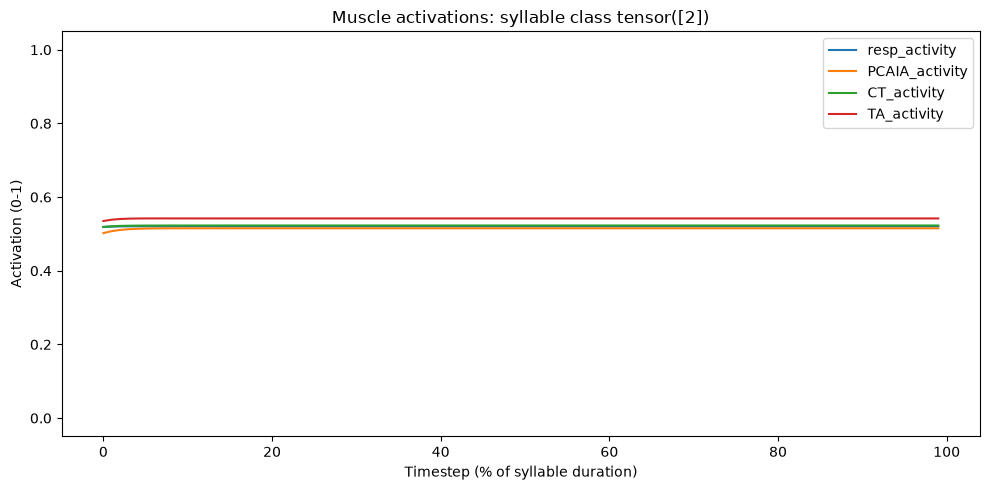

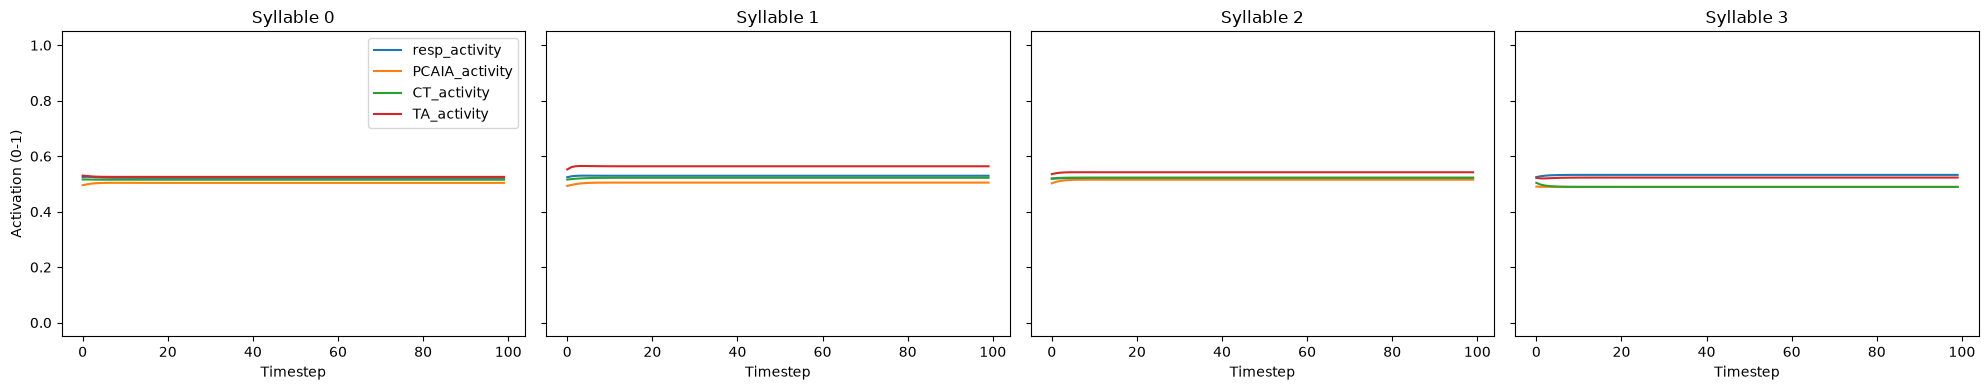

In [6]:
# --- visualizing the muscle activations ---

# single syllable
syllable_id = torch.tensor([2])
activations = model(syllable_id)
plot_activations(activations, syllable_id)

# compare a few syllables side by side
activations_dict = {}
for sid in [0, 1, 2, 3]:
    activations_dict[sid] = model(torch.tensor([sid]))
plot_activations_multi(activations_dict)